# Exercise 1: SVM on Quadratic Distribution Dataset

Generate a random dataset following a quadratic distribution and apply SVM with RBF kernel.

In [1]:
# CH.SC.U4CSE24119 Kavin JS

import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

## Generate Quadratic Dataset

In [2]:
np.random.seed(42)
n = 300
x1 = np.random.uniform(-3, 3, n)
x2 = np.random.uniform(-3, 3, n)

# Label: inside the parabola x2 < x1^2 -> class 0, else class 1
y = np.where(x2 < x1**2, 0, 1)

X = np.column_stack([x1, x2])
print('Shape:', X.shape)
print('Class distribution:', {0: (y==0).sum(), 1: (y==1).sum()})

Shape: (300, 2)
Class distribution: {0: np.int64(241), 1: np.int64(59)}


## Plot the Dataset

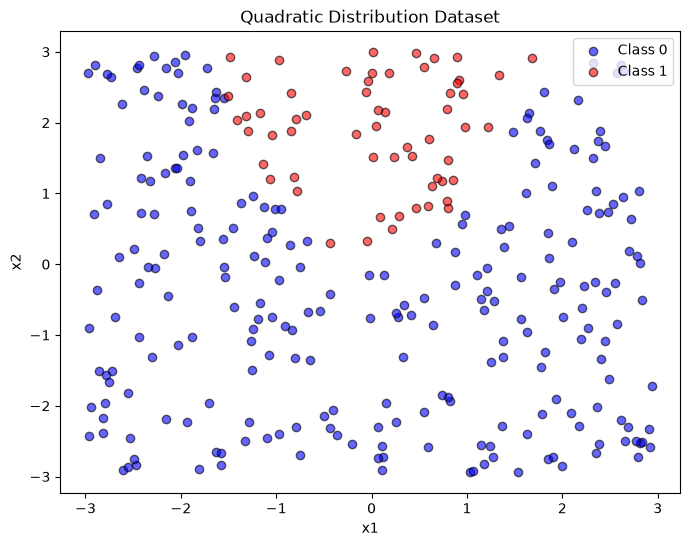

In [3]:
plt.figure(figsize=(8, 6))
plt.scatter(X[y==0, 0], X[y==0, 1], c='blue', label='Class 0', alpha=0.6, edgecolors='k')
plt.scatter(X[y==1, 0], X[y==1, 1], c='red', label='Class 1', alpha=0.6, edgecolors='k')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Quadratic Distribution Dataset')
plt.legend()
plt.show()

## Train SVM with RBF Kernel

In [4]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=5)

sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

mdl = SVC(kernel='rbf', random_state=0)
mdl.fit(x_train, y_train)
y_pred = mdl.predict(x_test)

## Evaluation

In [5]:
print('Accuracy:', int(accuracy_score(y_test, y_pred) * 100), '%')
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

Accuracy: 97 %

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        74
           1       1.00      0.88      0.93        16

    accuracy                           0.98        90
   macro avg       0.99      0.94      0.96        90
weighted avg       0.98      0.98      0.98        90



## Visualize Decision Boundary

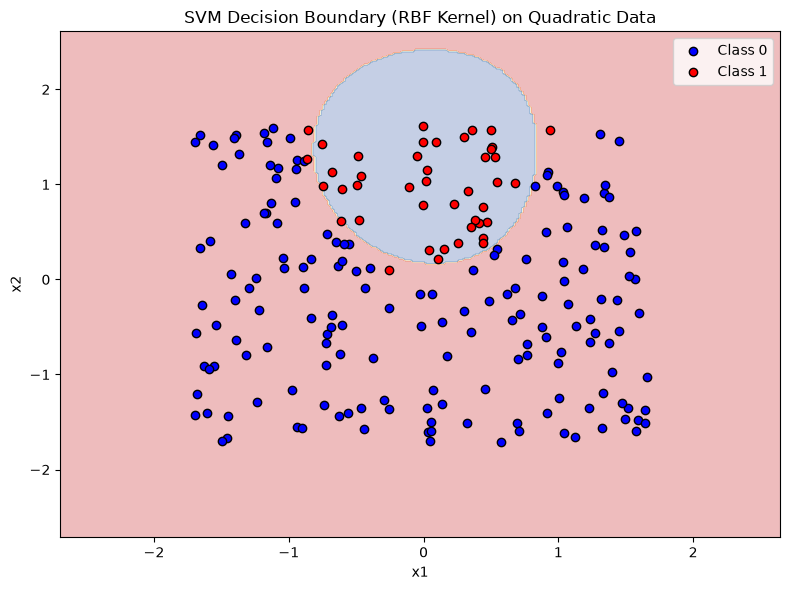

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))

# Create mesh
h = 0.02
x_min, x_max = x_train[:, 0].min() - 1, x_train[:, 0].max() + 1
y_min, y_max = x_train[:, 1].min() - 1, x_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = mdl.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
ax.scatter(x_train[y_train==0, 0], x_train[y_train==0, 1], c='blue', label='Class 0', edgecolors='k')
ax.scatter(x_train[y_train==1, 0], x_train[y_train==1, 1], c='red', label='Class 1', edgecolors='k')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_title('SVM Decision Boundary (RBF Kernel) on Quadratic Data')
ax.legend()
plt.tight_layout()
plt.show()